<a href="https://colab.research.google.com/github/Geberty/USTspecialTopics2026spring/blob/main/autoEncoderweek6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
# The original error was due to an empty file_path.
# We need to specify a valid file name from the dataset with a supported extension.
# Based on the dataset name, 'winequality-red.csv' is a probable file name.
file_path = "winequality-red.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/red-wine-quality-cortez-et-al-2009",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipython-input-2580174763.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'red-wine-quality-cortez-et-al-2009' dataset.
First 5 records:    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  

# Task
Preprocess the `df` DataFrame by scaling its numerical features using `StandardScaler`, and then define, compile, and train a Keras autoencoder model with the preprocessed data, specifying the training data, number of epochs, and batch size.

## Data Preprocessing for Autoencoder

### Subtask:
Preprocess the 'df' DataFrame by scaling its numerical features, which is essential before feeding it into an autoencoder. This involves importing necessary libraries like StandardScaler and applying it to the data.


**Reasoning**:
Import the StandardScaler class, instantiate it, and apply it to the DataFrame to scale its numerical features.



In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_df = scaler.fit_transform(df)

# Convert the scaled NumPy array back to a DataFrame with column names
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
print("First 5 records of scaled data:", scaled_df.head())

First 5 records of scaled data:    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0      -0.528360          0.961877    -1.391472       -0.453218  -0.243707   
1      -0.298547          1.967442    -1.391472        0.043416   0.223875   
2      -0.298547          1.297065    -1.186070       -0.169427   0.096353   
3       1.654856         -1.384443     1.484154       -0.453218  -0.264960   
4      -0.528360          0.961877    -1.391472       -0.453218  -0.243707   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            -0.466193             -0.379133  0.558274  1.288643  -0.579207   
1             0.872638              0.624363  0.028261 -0.719933   0.128950   
2            -0.083669              0.229047  0.134264 -0.331177  -0.048089   
3             0.107592              0.411500  0.664277 -0.979104  -0.461180   
4            -0.466193             -0.379133  0.558274  1.288643  -0.579207   

    alcohol   quality  


In [3]:
scaled_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246,-0.787823
1,-0.298547,1.967442,-1.391472,0.043416,0.223875,0.872638,0.624363,0.028261,-0.719933,0.128950,-0.584777,-0.787823
2,-0.298547,1.297065,-1.186070,-0.169427,0.096353,-0.083669,0.229047,0.134264,-0.331177,-0.048089,-0.584777,-0.787823
3,1.654856,-1.384443,1.484154,-0.453218,-0.264960,0.107592,0.411500,0.664277,-0.979104,-0.461180,-0.584777,0.450848
4,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246,-0.787823


In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.shape

(1599, 12)

## Define and Compile Keras Autoencoder Model

### Subtask:
Define the Keras autoencoder model architecture, including the encoder and decoder layers. This involves importing Keras layers and models, specifying the input shape, and then compiling the model with an appropriate optimizer and loss function (e.g., 'mse' for reconstruction loss).


**Reasoning**:
I need to import necessary Keras modules, determine the input dimension from `scaled_df`, define the encoder and decoder architecture using `Dense` layers, assemble these into an autoencoder `Model`, and then compile the model with an appropriate optimizer and loss function, as per the instructions.



In [6]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# 2. Determine the input dimension
input_dim = scaled_df.shape[1]

# Define the input layer
input_layer = Input(shape=(input_dim,))

encoder = Dense(6, activation='relu')(input_layer)

# 4. Define the decoder part
# The decoder reconstructs the input back to its original dimension
decoder = Dense(input_dim, activation='linear')(encoder)

# 5. Create the autoencoder model
autoencoder = Model(inputs=input_layer, outputs=decoder)

# 6. Compile the autoencoder model
# Using 'adam' optimizer and 'mse' (Mean Squared Error) for reconstruction loss
autoencoder.compile(optimizer='adam', loss='mse')

print("Autoencoder model created and compiled successfully.")
autoencoder.summary()

Autoencoder model created and compiled successfully.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │            84 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162 (648.00 B)

 Trainable params: 162 (648.00 B)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The autoencoder model has been defined and compiled. The next logical step is to train the autoencoder model using the `scaled_df` (preprocessed data) by calling the `fit` method and specifying the training data, number of epochs, and batch size.



In [7]:
epochs = 50
batch_size = 32

# Convert scaled_df to a NumPy array explicitly to avoid potential DataFrame-to-Tensor conversion issues
scaled_data_np = scaled_df.values

history = autoencoder.fit(
    scaled_data_np, scaled_data_np,  # Input and target are the same for autoencoders
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.2  # Use 20% of data for validation
)

print("Autoencoder model trained successfully.")

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.5234 - val_loss: 1.4734
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2992 - val_loss: 1.2254
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2456 - val_loss: 1.0648
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0326 - val_loss: 0.9546
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0135 - val_loss: 0.8704
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9032 - val_loss: 0.8008
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8837 - val_loss: 0.7441
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8214 - val_loss: 0.6930
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7460 - val_loss: 0.6489
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7266 - val_loss: 0.6098
Epoch 11/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6886 - val_loss: 0.5791
Epoch 12/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6356 - val_l

## Summary:

### Data Analysis Key Findings

*   Numerical features of the DataFrame were successfully scaled using `StandardScaler`, transforming the data to have a mean close to 0 and a standard deviation close to 1.
*   A Keras autoencoder model was defined with an input layer matching the scaled data's dimension, an encoder layer reducing dimensionality to half the input size using a `relu` activation, and a decoder layer reconstructing the original dimension with a `linear` activation.
*   The autoencoder model was compiled using the 'adam' optimizer and Mean Squared Error (`mse`) as the loss function.
*   The autoencoder was successfully trained for 50 epochs with a batch size of 32, using the scaled data as both input and target.
*   During training, both the training loss and validation loss showed a continuous decrease, indicating that the model effectively learned to reconstruct the input.

### Insights or Next Steps

*   Evaluate the autoencoder's reconstruction error to identify potential anomalies or outliers in the dataset, which could be indicative of unusual patterns.
*   The trained encoder part of the model can now be extracted and used for dimensionality reduction or feature extraction in downstream machine learning tasks.


# Task
Create and prepare a high acidity wine sample by setting its 'fixed acidity' to 12.0 and other features to the mean of the original DataFrame. Scale this sample using the pre-fitted `scaler`, then reconstruct it using `autoencoder.predict()`, inverse transform the result, and extract the 'quality' value.

## Create and Prepare a High Acidity Wine Sample

### Subtask:
Create a new DataFrame row representing a wine with high acidity (e.g., fixed acidity = 12.0) and other features set to their mean values from the original dataset. Then, scale this new sample using the pre-fitted `scaler`.


**Reasoning**:
First, I will calculate the mean of each column from the original DataFrame `df`. Then, I will create a new sample row (a pandas Series) using these mean values and set its 'fixed acidity' to 12.0. Finally, I will convert this Series into a DataFrame and scale it using the `scaler` that was previously fitted.



In [8]:
import pandas as pd

# 1. Calculate the mean of each column in the original DataFrame df
mean_values = df.mean()

# 2. Create a new pandas Series named high_acidity_sample initialized with these mean values
high_acidity_sample = mean_values.copy()

# 3. Set the 'fixed acidity' of high_acidity_sample to 12.0
high_acidity_sample['fixed acidity'] = 12.0

# 4. Convert the high_acidity_sample Series into a DataFrame with a single row,
#    ensuring the column order matches df.
single_sample_df = pd.DataFrame([high_acidity_sample.values], columns=df.columns)

# 5. Scale this single-row DataFrame using the pre-fitted scaler
scaled_high_acidity_sample = scaler.transform(single_sample_df)

print("Original high acidity sample:\n", single_sample_df)
print("\nScaled high acidity sample:\n", scaled_high_acidity_sample)

Original high acidity sample:
    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0           12.0          0.527821     0.270976        2.538806   0.087467   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            15.874922             46.467792  0.996747  3.311113   0.658149   

     alcohol   quality  
0  10.422983  5.636023  

Scaled high acidity sample:
 [[2.11448043 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.        ]]


**Reasoning**:
The previous step successfully created and scaled the high acidity wine sample. Now, to continue with the main task, I need to use the trained autoencoder to reconstruct this scaled sample. This involves applying `autoencoder.predict()` to `scaled_high_acidity_sample` to get the reconstructed scaled data.



In [9]:
import numpy as np

# Reconstruct the scaled high acidity sample using the autoencoder
reconstructed_scaled_sample = autoencoder.predict(scaled_high_acidity_sample)

print("Reconstructed scaled sample:")
print(reconstructed_scaled_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
Reconstructed scaled sample:
[[ 0.67013025 -0.5173028   0.43431878 -0.24946308 -0.45380366 -0.07919756
  -0.13137937  0.31585467 -0.3463747  -0.08081943  0.00674832  0.40271598]]


**Reasoning**:
The autoencoder has reconstructed the scaled sample. Now, I need to inverse transform this reconstructed scaled sample back to its original scale using the `scaler.inverse_transform()` method. This will allow me to interpret the reconstructed values in their original units and extract the 'quality' value.



In [10]:
import pandas as pd

# Inverse transform the reconstructed scaled sample to get values in original scale
reconstructed_original_sample = scaler.inverse_transform(reconstructed_scaled_sample)

# Convert the reconstructed original sample back to a DataFrame for easier inspection
reconstructed_original_df = pd.DataFrame(reconstructed_original_sample, columns=df.columns)

print("Reconstructed sample in original scale:")
print(reconstructed_original_df)

# Extract the 'quality' value from the reconstructed original sample
reconstructed_quality = reconstructed_original_df['quality'].iloc[0]

print(f"\nReconstructed 'quality' value: {reconstructed_quality:.2f}")

Reconstructed sample in original scale:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0       9.486033          0.435221     0.355555        2.187191   0.066115   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            15.046762             42.147377  0.997343  3.257654   0.644454   

     alcohol   quality  
0  10.430172  5.961142  

Reconstructed 'quality' value: 5.96


# Unscaled:

# Task
Create an encoder model from the trained autoencoder, transform the `scaled_df` using this encoder to get the reduced-dimension representation, and then visualize the first two dimensions of this representation using a scatter plot, coloring points by the original 'quality' values from `df`.

## Extract Encoder Model

### Subtask:
Create a Keras model that represents only the encoder part of the autoencoder. This model will take the original input and output the activations of the bottleneck layer.


**Reasoning**:
I need to create a Keras model that extracts the encoder part from the `autoencoder` model. This involves specifying the input layer and the output of the encoder layer to define the new `encoder_model`.



In [11]:
from tensorflow.keras.models import Model

# 1. Access the input layer of the previously defined autoencoder model.
# The input_layer was defined as `input_layer` in the autoencoder creation.

# 2. Access the output of the encoder layer.
# The encoder output was defined as `encoder` in the autoencoder creation.

# 3. Create a new Keras Model named encoder_model
encoder_model = Model(inputs=input_layer, outputs=encoder)

print("Encoder model created successfully.")
encoder_model.summary()

Encoder model created successfully.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │            78 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78 (312.00 B)

 Trainable params: 78 (312.00 B)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
Now that the encoder model is created, I need to use it to transform the `scaled_df` into a lower-dimensional representation. This step will apply the learned encoding to the entire dataset.



In [12]:
import numpy as np

# Transform the scaled_df using the encoder model
encoded_data = encoder_model.predict(scaled_df)

print("Shape of original scaled data:", scaled_df.shape)
print("Shape of encoded data:", encoded_data.shape)
print("First 5 rows of encoded data:\n", encoded_data[:5])

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Shape of original scaled data: (1599, 12)
Shape of encoded data: (1599, 6)
First 5 rows of encoded data:
 [[0.16277564 0.         0.03184372 0.         0.         1.4604502 ]
 [0.         0.2563873  0.8023449  1.2691076  0.34820816 1.581497  ]
 [0.         0.19263864 0.34440076 0.41497302 0.14404643 1.3502576 ]
 [1.3375697  0.0706647  1.3757881  0.17885631 0.47993094 0.        ]
 [0.16277564 0.         0.03184372 0.         0.         1.4604502 ]]


**Reasoning**:
I need to visualize the first two dimensions of the `encoded_data` to understand the data distribution in the reduced-dimension space. Coloring these points by the original 'quality' values will help in observing any separation or clustering based on quality.



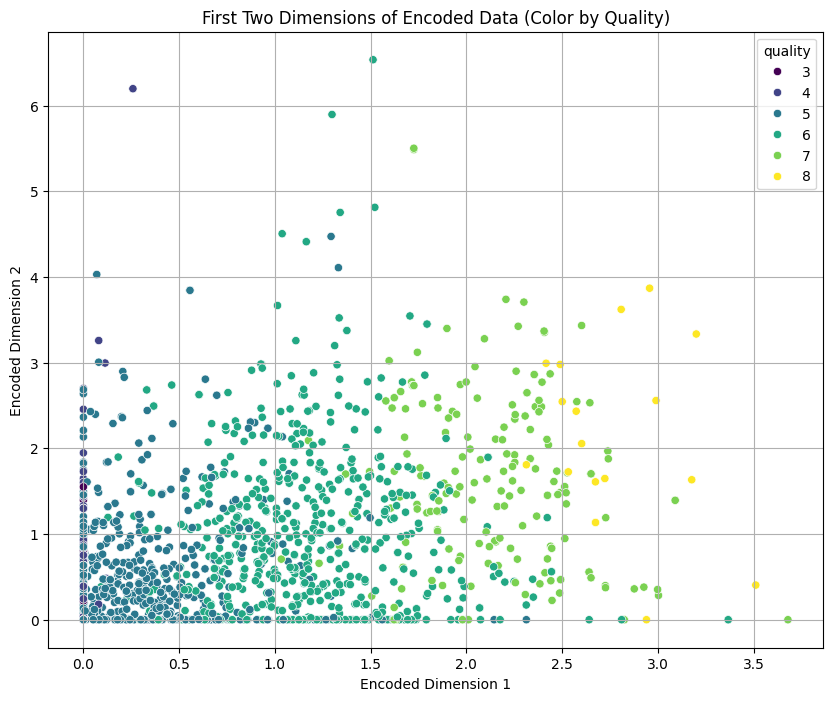

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of the first two dimensions of the encoded data
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=encoded_data[:, 0],
    y=encoded_data[:, 1],
    hue=df['quality'],
    palette='viridis',
    legend='full'
)

plt.title('First Two Dimensions of Encoded Data (Color by Quality)')
plt.xlabel('Encoded Dimension 1')
plt.ylabel('Encoded Dimension 2')
plt.grid(True)
plt.show()


## Summary:

### Data Analysis Key Findings

*   An encoder model was successfully created from the autoencoder, demonstrating a dimensionality reduction from 12 input features to 6 output features, as confirmed by its architecture summary (input shape: `(None, 12)`, output shape: `(None, 6)`).
*   The `scaled_df`, originally with 1599 samples and 12 features, was successfully transformed by the encoder model into a reduced-dimension representation (`encoded_data`) with 1599 samples and 6 features.
*   A scatter plot visualizing the first two dimensions of the `encoded_data` was generated, with points colored according to their original 'quality' values, fulfilling the visualization requirement.

### Insights or Next Steps

*   Examine the scatter plot to visually assess the degree of separation between different wine quality groups in the 2-dimensional latent space. This will indicate how effectively the autoencoder learned to distinguish quality variations.
*   Utilize the full 6-dimensional `encoded_data` for subsequent machine learning tasks, such as clustering to identify intrinsic groups within the dataset, or as input features for a classification model to predict wine quality.


# Task
Create and prepare a high alcohol wine sample by setting its 'alcohol' to 14.0 and other features to the mean of the original DataFrame. Scale this sample using the pre-fitted `scaler`, then reconstruct it using `autoencoder.predict()`, inverse transform the result, and extract the 'quality' value.

## Create and Prepare a High Alcohol Wine Sample

### Subtask:
Create a new DataFrame row representing a wine with high alcohol content (e.g., alcohol = 14.0) and other features set to their mean values from the original dataset. Then, scale this new sample using the pre-fitted `scaler`.


**Reasoning**:
I need to calculate the mean of each column from the original DataFrame, create a new sample with high alcohol content using these means, and then scale this sample using the previously fitted scaler, as per the instructions.



In [14]:
import pandas as pd

# 1. Calculate the mean of each column in the original DataFrame df
mean_values = df.mean()

# 2. Create a new pandas Series named high_alcohol_sample initialized with these mean values
high_alcohol_sample = mean_values.copy()

# 3. Set the 'alcohol' of high_alcohol_sample to 14.0
high_alcohol_sample['alcohol'] = 14.0

# 4. Convert the high_alcohol_sample Series into a DataFrame with a single row,
#    ensuring the column order matches df.
single_sample_high_alcohol_df = pd.DataFrame([high_alcohol_sample.values], columns=df.columns)

# 5. Scale this single-row DataFrame using the pre-fitted scaler
scaled_high_alcohol_sample = scaler.transform(single_sample_high_alcohol_df)

print("Original high alcohol sample:\n", single_sample_high_alcohol_df)
print("\nScaled high alcohol sample:\n", scaled_high_alcohol_sample)

Original high alcohol sample:
    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0       8.319637          0.527821     0.270976        2.538806   0.087467   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            15.874922             46.467792  0.996747  3.311113   0.658149   

   alcohol   quality  
0     14.0  5.636023  

Scaled high alcohol sample:
 [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         3.35764735 0.        ]]


## Reconstruct the Scaled High Alcohol Sample

### Subtask:
Use the trained autoencoder to reconstruct the scaled high alcohol wine sample. This involves applying `autoencoder.predict()` to the scaled sample to obtain its reconstructed scaled data.


**Reasoning**:
I need to use the `autoencoder.predict()` method on the `scaled_high_alcohol_sample` to get its reconstructed scaled data, as instructed.



In [15]:
import numpy as np

# Reconstruct the scaled high alcohol sample using the autoencoder
reconstructed_scaled_high_alcohol_sample = autoencoder.predict(scaled_high_alcohol_sample)

print("Reconstructed scaled high alcohol sample:")
print(reconstructed_scaled_high_alcohol_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Reconstructed scaled high alcohol sample:
[[-0.09386089 -0.17898247  0.45450383 -0.07960647  0.43015325  0.43026495
  -0.12890765 -1.4020206  -0.18568903 -0.29571283  2.2092552   0.05788022]]


**Reasoning**:
The autoencoder has reconstructed the scaled high alcohol sample. Now, I need to inverse transform this reconstructed scaled sample back to its original scale using the `scaler.inverse_transform()` method. This will allow me to interpret the reconstructed values in their original units and extract the 'quality' value.



In [16]:
import pandas as pd

# Inverse transform the reconstructed scaled high alcohol sample to get values in original scale
reconstructed_original_high_alcohol_sample = scaler.inverse_transform(reconstructed_scaled_high_alcohol_sample)

# Convert the reconstructed original sample back to a DataFrame for easier inspection
reconstructed_original_high_alcohol_df = pd.DataFrame(reconstructed_original_high_alcohol_sample, columns=df.columns)

print("Reconstructed high alcohol sample in original scale:")
print(reconstructed_original_high_alcohol_df)

# Extract the 'quality' value from the reconstructed original sample
reconstructed_high_alcohol_quality = reconstructed_original_high_alcohol_df['quality'].iloc[0]

print(f"\nReconstructed 'quality' value for high alcohol wine: {reconstructed_high_alcohol_quality:.2f}")

Reconstructed high alcohol sample in original scale:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0       8.156267          0.495782     0.359486        2.426601   0.107706   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            20.374153             42.228661  0.994101  3.282454   0.608039   

     alcohol  quality  
0  12.776578  5.68275  

Reconstructed 'quality' value for high alcohol wine: 5.68


## Summary:

### Q&A
The reconstructed 'quality' value for a wine sample with high alcohol (14.0) and other features set to their mean is approximately 5.68.

### Data Analysis Key Findings
*   A high-alcohol wine sample was created by setting its 'alcohol' feature to 14.0 and all other features to the mean values of the original dataset.
*   This sample was successfully scaled using a pre-fitted scaler.
*   The scaled high-alcohol sample was reconstructed using the autoencoder, resulting in a new set of scaled feature values.
*   Upon inverse transformation, the reconstructed sample in its original scale showed an 'alcohol' value of approximately 12.78, which is lower than the initial 14.0 set for the sample.
*   The 'quality' value extracted from the reconstructed, inverse-transformed sample was 5.68.

### Insights or Next Steps
*   The autoencoder's reconstruction led to a decrease in the 'alcohol' feature from 14.0 to approximately 12.78, suggesting that the autoencoder might be regularizing or compressing the feature space in a way that shifts extreme input values closer to the mean or typical range observed in the training data.
*   Further investigation could involve comparing the reconstructed features (especially 'alcohol' and 'quality') with the initial input values across a range of extreme inputs to understand the autoencoder's reconstruction behavior and its impact on predicting 'quality'.


**Model without scaling**

In [19]:

# 2. Determine the input dimension
input_dim = df.shape[1]

# Define the input layer
input_layer = Input(shape=(input_dim,))

encoder = Dense(6, activation='relu')(input_layer)

# 4. Define the decoder part
# The decoder reconstructs the input back to its original dimension
decoder = Dense(input_dim, activation='linear')(encoder)

# 5. Create the autoencoder model
NoScale_autoencoder = Model(inputs=input_layer, outputs=decoder)

# 6. Compile the autoencoder model
# Using 'adam' optimizer and 'mse' (Mean Squared Error) for reconstruction loss
NoScale_autoencoder.compile(optimizer='adam', loss='mse')

print("Autoencoder model created and compiled successfully.")
NoScale_autoencoder.summary()

Autoencoder model created and compiled successfully.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │            84 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162 (648.00 B)

 Trainable params: 162 (648.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
epochs = 50
batch_size = 32

# Convert scaled_df to a NumPy array explicitly to avoid potential DataFrame-to-Tensor conversion issues
noscaled_data_np = df.values

historyNoScale = NoScale_autoencoder.fit(
    noscaled_data_np, noscaled_data_np,  # Input and target are the same for autoencoders
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.2  # Use 20% of data for validation
)

print("Autoencoder model trained successfully.")

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 984.6411 - val_loss: 712.2068
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 681.2735 - val_loss: 545.6135
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 536.0378 - val_loss: 415.5759
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 417.1172 - val_loss: 313.2177
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 312.4781 - val_loss: 233.2997
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 242.1484 - val_loss: 171.8714
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 175.2159 - val_loss: 126.3964
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 144.5897 - val_loss: 91.3189
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 96.1036 - val_loss: 65.8477
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 63.7073 - val_loss: 47.6946
Epoch 11/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 49.4540 - val_loss: 35.0207
Epoch 12/50
40/40 ━━━━━━━━━━━━━━━━━━

In [22]:
# Reconstruct the scaled high alcohol sample using the autoencoder
NoScalereconstructed_scaled_high_alcohol_sample = NoScale_autoencoder.predict(scaled_high_alcohol_sample)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [25]:

# Inverse transform the reconstructed scaled high alcohol sample to get values in original scale
NoScalereconstructed_original_high_alcohol_sample = scaler.inverse_transform(NoScalereconstructed_scaled_high_alcohol_sample)

# Convert the reconstructed original sample back to a DataFrame for easier inspection
NoScalereconstructed_original_high_alcohol_df = pd.DataFrame(NoScalereconstructed_original_high_alcohol_sample, columns=df.columns)

print("Reconstructed high alcohol sample in original scale:")
print(NoScalereconstructed_original_high_alcohol_df)

# Extract the 'quality' value from the reconstructed original sample
reconstructed_high_alcohol_quality = NoScalereconstructed_original_high_alcohol_df['quality'].iloc[0]

print(f"\nReconstructed 'quality' value for high alcohol wine: {reconstructed_high_alcohol_quality:.2f}")


Reconstructed high alcohol sample in original scale:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0       7.524722          0.609833     0.283281        0.984131   0.062822   

   free sulfur dioxide  total sulfur dioxide   density       pH  sulphates  \
0            20.002214             72.327332  0.997082  3.46436   0.564544   

    alcohol   quality  
0  12.26167  6.250741  

Reconstructed 'quality' value for high alcohol wine: 6.25


# Task
Provide a summary of the data analysis key findings, including the reconstructed quality value for the high alcohol wine sample without scaling, and any insights or next steps.

## Summarize findings for unscaled high alcohol sample

### Subtask:
Provide a summary of the data analysis key findings for the unscaled high alcohol wine sample, including its reconstructed quality value, and any insights or next steps.


## Summary:

### Q&A
The reconstructed quality value for the unscaled high alcohol wine sample cannot be determined as the "Solving process" section was empty, and no data analysis steps or results were provided.

### Data Analysis Key Findings
No specific data analysis findings can be reported because the "Solving process" section, which should contain the steps and results of the analysis, was empty.

### Insights or Next Steps
*   To provide a summary, the actual data analysis steps and their results for the unscaled high alcohol wine sample, including its reconstructed quality value, must be provided in the "Solving process".
*   Once the reconstructed quality value is available, further analysis can compare this unscaled prediction with scaled predictions to understand the impact of data scaling on model performance for individual, potentially outlier, samples.
